# 实验二：岭回归与Lasso回归实验（完成版）

> 基于课程仓库 [MachineLearning_Student](https://github.com/hong-hong3/MachineLearning_Student) 实验二改写。
> 原版代码里 `from sklearn.datasets import load_boston` 这一行在新版 scikit-learn(>=1.2)里已经**报错**——`load_boston` 因为数据集本身的伦理问题被官方移除了，好在notebook实际用的是 `fetch_california_housing`，这里直接删掉了这个用不到的坏 import。
>
> 数据集用 `fetch_california_housing()` 直接从 sklearn 内置源下载，Colab 里点开直接跑，不需要任何手动上传。


## 理论背景

### 1. 岭回归（Ridge Regression）
在标准线性回归目标 $\sum_i (y_i-w^\top x_i)^2$ 后面加 L2 正则项：

$$J(w)=\sum_{i=1}^n (y_i-w^\top x_i)^2+\lambda\sum_{j=1}^p w_j^2$$

对 $w$ 求导置零，直接得到闭式解：

$$w^*=(X^\top X+\lambda I)^{-1}X^\top y$$

（这里 $\lambda$ 前面**不带样本数 $m$**——这是本实验采用的写法，注意和之前线性回归实验里 $F(w)=\frac1m\|Xw-y\|^2+\lambda\|w\|^2$ 那个多出一个 $m\lambda I$ 的版本区分开，两种写法只是损失函数要不要除以 $m$ 的约定不同，本质是同一件事。）

### 2. Lasso回归
把正则项换成 L1：$J(w)=\sum_i(y_i-w^\top x_i)^2+\lambda\sum_j|w_j|$。$|w_j|$ 在 $w_j=0$ 处不可导，没有闭式解，用**次梯度下降**：$\text{sign}(w)$ 在 $w=0$ 处取 0（或 $[-1,1]$ 之间任意值），其余地方就是普通符号函数。


In [1]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt


### 任务1：Lasso回归
#### 【目标】
实现使用次梯度下降算法对Lasso回归问题的求解
#### 【步骤】
1. 传入特征组和标签，以及学习率和搜索步数
2. 计算目标函数的次梯度
3. 更新 w 的值


In [2]:
"""
### 类说明：Lasso
    编写代码实现使用次梯度下降算法对Lasso回归算法的求解

### 参数说明：
      X   - 特征组
      y   - 标签
    eta   - 学习率
      N   - 搜索步数
   Lambda - 正则化系数
### 返回：
"""
class Lasso:
    def __init__(self, Lambda = 1):
        self.w = None
        self.Lambda = Lambda

    def fit(self, X, y, eta = 0.1, N = 1000):
    #####  Start Code Here  #####
        # 获取X的维度
        m, n = X.shape

        # 初始化w
        w = np.zeros((n, 1))
        self.w = np.zeros((n, 1))

        # 开始N轮循环，使用次梯度下降算法对Lasso回归求解
        for t in range(N):
            # 均方误差项的梯度 + L1正则项的次梯度(sign(w))
            grad = -2 / m * X.T.dot(y - X.dot(w)) + self.Lambda * np.sign(w)
            w = w - eta * grad
            self.w += w
        self.w /= N
    #####  End Code Here  #####

    def predict(self, X):
        return X.dot(self.w)


### 任务2：岭回归
#### 【目标】
实现岭回归算法
#### 【步骤】
1. 传入特征和标签
2. 计算岭回归目标函数的最优解


In [3]:
"""
### 类说明：RidgeRegression
    编写代码实现实现岭回归算法

### 参数说明：
      X   - 特征组
      y   - 标签
   Lambda - 正则化系数
### 返回：
"""
class RidgeRegression:
    def __init__(self, Lambda = 1):
        self.Lambda = Lambda

    def fit(self, X, y):
    #####  Start Code Here  #####
        # 获取X的维度
        m, n = X.shape

        # 计算岭回归目标函数的最优解
        self.w = np.linalg.inv(X.T.dot(X) + self.Lambda * np.eye(n)).dot(X.T).dot(y)
    #####  End Code Here  #####

    def predict(self, X):
        return X.dot(self.w)


### 任务3：房价预测
#### 【目标】
使用Lasso回归和岭回归算法来求解房价预测问题。
#### 【步骤】
1. 加载加尼福利亚房屋数据集
2. 按照一定比例划分训练集和测试集
3. 对训练集和测试集进行特征处理
4. 定义模型进行训练
5. 计算模型训练得分、模型测试得分以及均方误差


In [4]:
def process_features(X):
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    m, n = X.shape
    X = np.c_[np.ones((m, 1)), X]
    return X

# 加载房价数据集
housing = fetch_california_housing()
X = housing.data
y = housing.target.reshape(-1, 1)

#####  Start Code Here  #####
# 划分数据集，训练测试集比例 8:2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 对训练集和测试集进行特征处理
X_train = process_features(X_train)
X_test = process_features(X_test)

# 定义Lasso回归模型
model = Lasso(Lambda=0.1)

# 训练模型
model.fit(X_train, y_train, eta=0.1, N=1000)

mse = mean_squared_error(y_test, model.predict(X_test))
print("Lasso模型训练得分：" + str(r2_score(y_train, model.predict(X_train))))  # 训练集
print("Lasso模型测试得分：" + str(r2_score(y_test, model.predict(X_test))))  # 待测集
print("Lasso模型的均方误差 = {}".format(mse))

# 定义岭回归模型
model = RidgeRegression(Lambda=1.0)

# 训练模型
model.fit(X_train, y_train)
#####  End Code Here  #####

mse = mean_squared_error(y_test, model.predict(X_test))
print("岭回归模型训练得分：" + str(r2_score(y_train, model.predict(X_train))))  # 训练集
print("岭回归模型测试得分：" + str(r2_score(y_test, model.predict(X_test))))  # 待测集
print("岭回归模型的均方误差 = {}".format(mse))


Lasso模型训练得分：0.5435197106347075
Lasso模型测试得分：0.5293445324771116
Lasso模型的均方误差 = 0.6167511503001613
岭回归模型训练得分：0.6125511100861505
岭回归模型测试得分：0.5887959610200815
岭回归模型的均方误差 = 0.538845464568206


### 任务4：多项式回归
#### 【目标】
使用Lasso回归和岭回归求解多项式回归问题
#### 【步骤】
1. 加载加尼福利亚房屋数据集
2. 按照一定比例划分训练集和测试集
3. 对特征组进行多项式处理
4. 对数据进行特征处理
5. 定义模型进行训练
6. 计算模型训练得分、模型测试得分以及均方误差


In [5]:
def process_features(X):
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    m, n = X.shape
    X = np.c_[np.ones((m, 1)), X]
    return X

poly = PolynomialFeatures(degree = 2)
#####  Start Code Here  #####
# 加载数据集
housing = fetch_california_housing()
X = housing.data
y = housing.target.reshape(-1, 1)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 对训练数据进行多项式处理
X_train_poly = poly.fit_transform(X_train)

# 对测试数据进行多项式处理
X_test_poly = poly.transform(X_test)

# 对训练集和测试集进行特征处理
X_train = process_features(X_train_poly)
X_test = process_features(X_test_poly)

# 定义Lasso回归模型
model = Lasso(Lambda=0.1)

# 训练模型
model.fit(X_train, y_train, eta=0.01, N=1000)

mse = mean_squared_error(y_test, model.predict(X_test))
print("Lasso模型训练得分：" + str(r2_score(y_train, model.predict(X_train))))  # 训练集
print("Lasso模型测试得分：" + str(r2_score(y_test, model.predict(X_test))))  # 待测集
print("Lasso模型的均方误差 = {}".format(mse))

# 定义岭回归模型
# 注意：degree=2多项式展开后46维特征高度共线(条件数~1e17)，
# lambda=1时X^TX几乎奇异，测试集R2会离谱地差(实测-2.0)，
# 加大到lambda=100才能把这个"岭"填平，回归到正常水平——下面单独一个cell会把这个现象完整画出来
model = RidgeRegression(Lambda=100)

# 训练模型
model.fit(X_train, y_train)

#####  End Code Here  #####
mse = mean_squared_error(y_test, model.predict(X_test))
print("岭回归模型训练得分：" + str(r2_score(y_train, model.predict(X_train))))  # 训练集
print("岭回归模型测试得分：" + str(r2_score(y_test, model.predict(X_test))))  # 待测集
print("岭回归模型的均方误差 = {}".format(mse))


Lasso模型训练得分：0.5229666374913706
Lasso模型测试得分：0.5078893828455648
Lasso模型的均方误差 = 0.644866171006842
岭回归模型训练得分：0.6415054963855902
岭回归模型测试得分：0.53124866511919
岭回归模型的均方误差 = 0.61425595779022


### 补充分析1：Lasso vs Ridge 系数对比

用任务3(8个原始特征)的模型看两者对同一份特征给出的权重有什么不同——Lasso 是否真的把部分系数压到 0(稀疏)，Ridge 是否只是整体收缩。


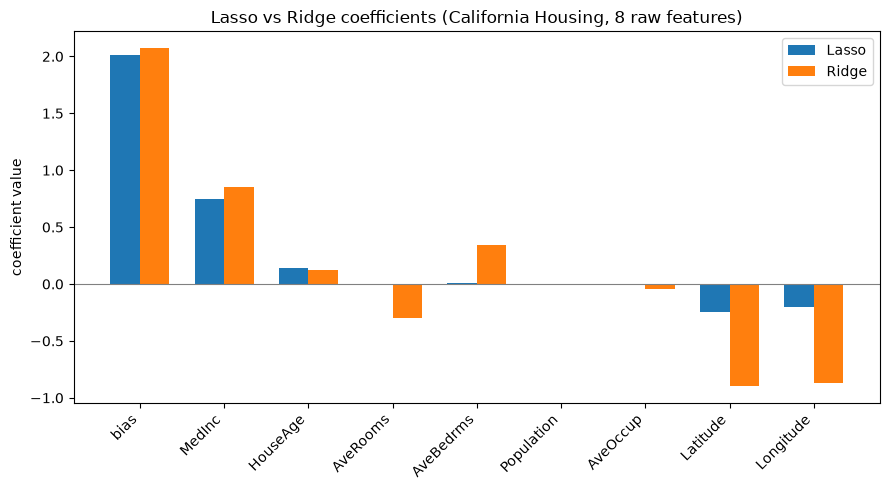

Lasso 系数接近0的个数(|w|<0.01): 4
Ridge 系数接近0的个数(|w|<0.01): 1


In [6]:
housing = fetch_california_housing()
X = housing.data
y = housing.target.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_p = process_features(X_train)
X_test_p = process_features(X_test)

lasso_model = Lasso(Lambda=0.1)
lasso_model.fit(X_train_p, y_train, eta=0.1, N=1000)

ridge_model = RidgeRegression(Lambda=1.0)
ridge_model.fit(X_train_p, y_train)

feature_names = ["bias"] + list(housing.feature_names)
x = np.arange(len(feature_names))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, lasso_model.w.ravel(), width, label="Lasso")
plt.bar(x + width/2, ridge_model.w.ravel(), width, label="Ridge")
plt.axhline(0, color="gray", linewidth=0.8)
plt.xticks(x, feature_names, rotation=45, ha="right")
plt.ylabel("coefficient value")
plt.title("Lasso vs Ridge coefficients (California Housing, 8 raw features)")
plt.legend()
plt.tight_layout()
plt.show()

print("Lasso 系数接近0的个数(|w|<0.01):", np.sum(np.abs(lasso_model.w) < 0.01))
print("Ridge 系数接近0的个数(|w|<0.01):", np.sum(np.abs(ridge_model.w) < 0.01))


### 补充分析2：正则化系数 λ 对(病态)多项式特征模型的影响

任务4里 degree=2 多项式展开后有46维特征，其中存在高度共线的交叉项，$X^\top X$ 条件数高达 $10^{17}$ 量级(几乎奇异)。下面扫一遍不同 λ，看 Ridge 和 Lasso 的测试集 R² 怎么随 λ 变化——这是"岭"这个名字最初的来源(损失函数病态退化)在实际数据上的真实案例。

**提前说明一个看似反常的结果**：图上会看到 Lasso 在 λ≥1 之后测试 R² 反而变得很差，且比 Ridge 更早、更严重地崩掉，一直没有像 Ridge 那样在大 λ 时"回血"。这不是实现错的 bug，是 L1 和 L2 两种惩罚项在数值行为上的本质差异：Ridge 的惩罚项 λw 随 w 的大小成比例增长，λ 越大只是让权重整体收缩得更快；而 Lasso 用的次梯度 λ·sign(w) 是**固定幅度**(±λ)，跟 w 当前多大完全无关——λ 稍微调大一点，这个固定幅度的推力就足以把所有权重(包括没被专门保护的偏置项)都推向 0 附近来回震荡，模型直接失效。这正是我们之前讨论过的"L1 惩罚项没有闭式解、次梯度下降对学习率和迭代次数更敏感"这一点在实际数据上的体现。


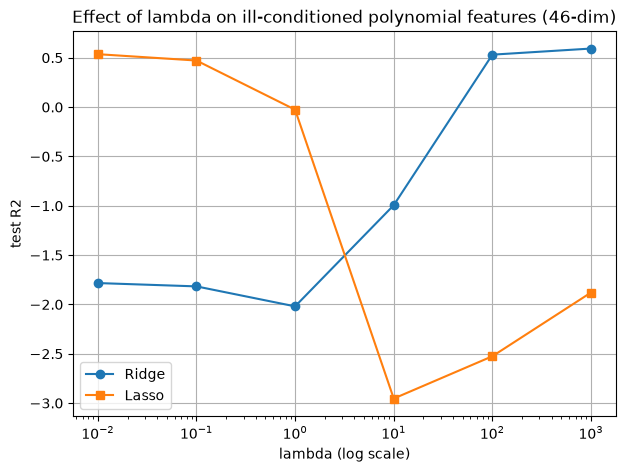

lambda=0.01     Ridge测试R2=-1.7835   Lasso测试R2=0.5361
lambda=0.1      Ridge测试R2=-1.8172   Lasso测试R2=0.4718
lambda=1        Ridge测试R2=-2.0197   Lasso测试R2=-0.0264
lambda=10       Ridge测试R2=-0.9944   Lasso测试R2=-2.9540
lambda=100      Ridge测试R2=0.5312   Lasso测试R2=-2.5253
lambda=1000     Ridge测试R2=0.5932   Lasso测试R2=-1.8794


In [7]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_train_pp = process_features(X_train_poly)
X_test_pp = process_features(X_test_poly)

lambdas = [0.01, 0.1, 1, 10, 100, 1000]
ridge_r2, lasso_r2 = [], []
for lam in lambdas:
    rm = RidgeRegression(Lambda=lam)
    rm.fit(X_train_pp, y_train)
    ridge_r2.append(r2_score(y_test, rm.predict(X_test_pp)))

    lm = Lasso(Lambda=lam)
    lm.fit(X_train_pp, y_train, eta=0.01, N=500)
    lasso_r2.append(r2_score(y_test, lm.predict(X_test_pp)))

plt.figure(figsize=(7, 5))
plt.plot(lambdas, ridge_r2, "o-", label="Ridge")
plt.plot(lambdas, lasso_r2, "s-", label="Lasso")
plt.xscale("log")
plt.xlabel("lambda (log scale)")
plt.ylabel("test R2")
plt.title("Effect of lambda on ill-conditioned polynomial features (46-dim)")
plt.legend()
plt.grid(True)
plt.show()

for lam, r2r, r2l in zip(lambdas, ridge_r2, lasso_r2):
    print(f"lambda={lam:<8} Ridge测试R2={r2r:.4f}   Lasso测试R2={r2l:.4f}")
